In [38]:
%load auto_reload
%auto_reload 2

ValueError: 'auto_reload' was not found in history, as a file, url, nor in the user namespace.

In [39]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [40]:
methods = ['nearest', 'bilinear', 'bicubic', 'lanczos3', 'random']

{
  loss: {
    training: list of 10000 items: [3.47, ..., 0.443]
  }
}


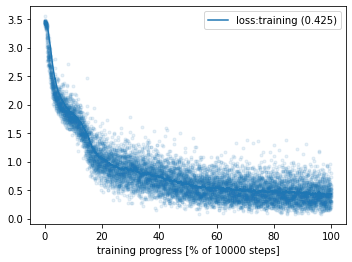

In [41]:
i = 0
name = f'bayesian-train-test/performance_{methods[i]}.json'
from helpers import results_data, utils, plots

perf = results_data.load(name)
utils.printd(perf)

plots.perf(perf, alpha=0.01)

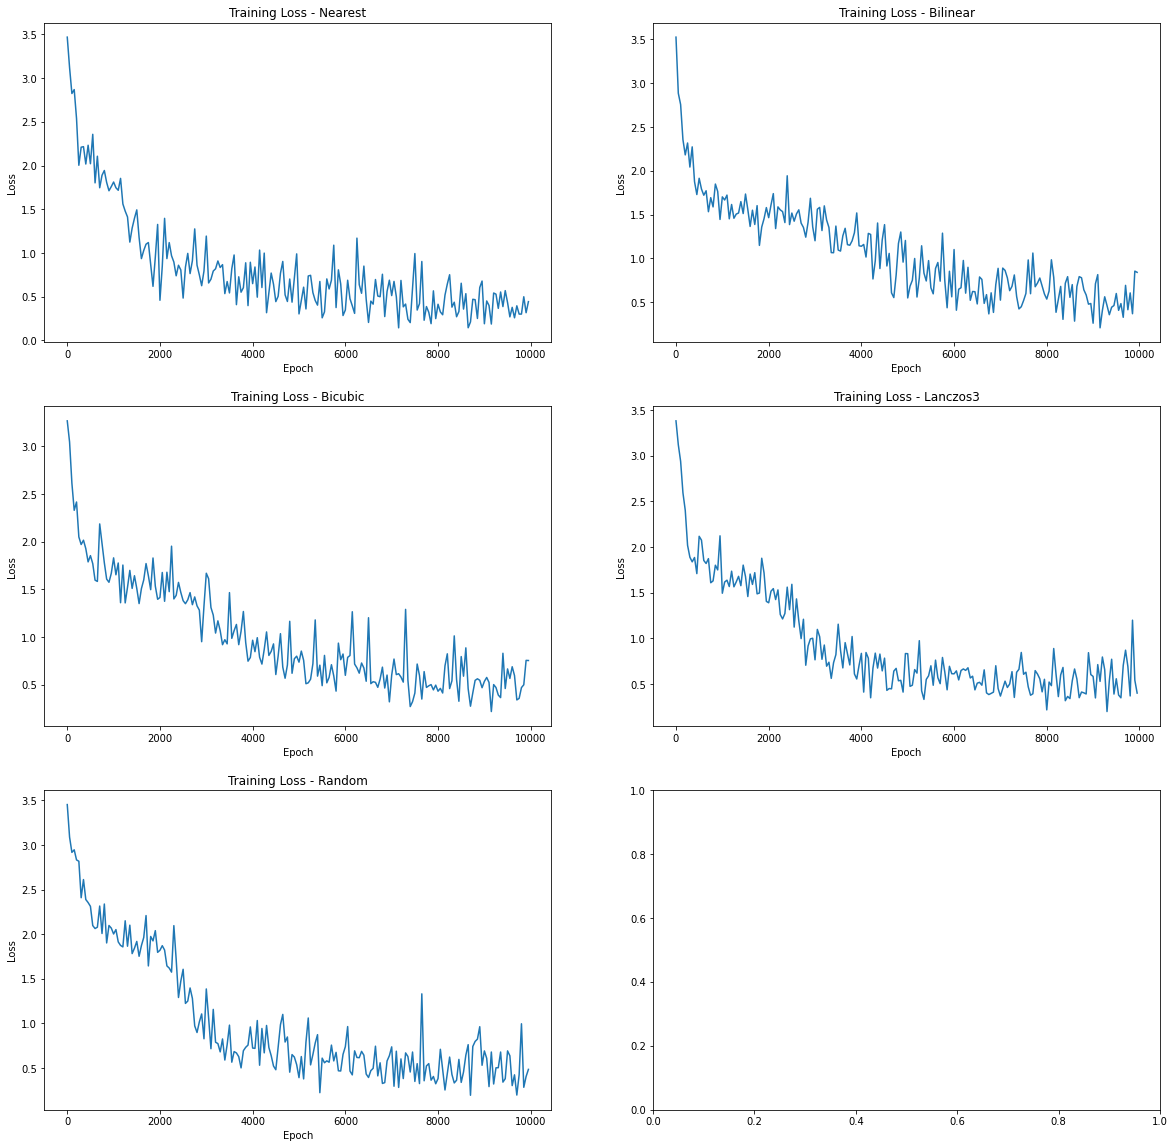

In [42]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 20]
fig, axs = plt.subplots(3, 2)
ax_list = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0)]

x_axis = np.reshape(np.arange(10000), (200, 50))[:, 0]

for i in range(len(methods)):
    with open(f'bayesian-train-test/performance_{methods[i]}.json', 'r') as f:
        performance = json.load(f)['loss']['training']
    performance = np.reshape(performance, (200, 50))
    
    axs[ax_list[i]].plot(x_axis, performance[:, -1])
    axs[ax_list[i]].set_title(f'Training Loss - {methods[i].capitalize()}')
    axs[ax_list[i]].set_xlabel('Epoch')
    axs[ax_list[i]].set_ylabel('Loss')

In [43]:
import pandas as pd
from collections import Counter
from scipy.special import softmax

In [44]:
def get_pred(arr):
    return max(k for k, v in Counter([np.argmax(x) for x in arr]).items() if v > 1)

def variation_ratio(X):
    probs = np.array([softmax(x) for x in X])
    n_passes = probs.shape[0]

    means = np.array([np.sum(c) / n_passes for c in probs.T])

    return 1 - means[np.argmax(means)]

def predictive_entropy(X):
    probs = np.array([softmax(x) for x in X])
    n_passes = probs.shape[0]
    
    means = np.array([np.sum(c) / n_passes for c in probs.T])

    return -np.sum(np.multiply(means, np.divide(np.log(np.clip(means, 1e-12, None)), np.log(n_passes))))

def mutual_information(X):
    probs = np.array([softmax(x) for x in X])
    n_passes = probs.shape[0]
    
    pred_ent = predictive_entropy(X)
    exp_value = np.divide(np.sum(np.multiply(probs, np.divide(np.log(np.clip(probs, 1e-12, None)), np.log(n_passes)))), n_passes)
    
    return pred_ent + exp_value

In [45]:
accuracy = pd.DataFrame(np.zeros((5, 4)), index=methods, columns=methods[:-1])
var_ratio = pd.DataFrame(np.zeros((5, 4)), index=methods, columns=methods[:-1])
pred_ent = pd.DataFrame(np.zeros((5, 4)), index=methods, columns=methods[:-1])
mutual_info = pd.DataFrame(np.zeros((5, 4)), index=methods, columns=methods[:-1])

classes = np.linspace(0.25, 1, num=31)
conf_matrices = {'nearest': np.zeros((31, 31)),
                 'bilinear': np.zeros((31, 31)),
                 'bicubic': np.zeros((31, 31)),
                 'lanczos3': np.zeros((31, 31)),
                 'random': np.zeros((31, 31))}

for method_1 in methods:
    with open(f'bayesian-train-test/tests_{method_1}.json', 'r') as f:
        tests = json.load(f)
        
    for method_2 in methods[:-1]:
        method_2_tests = [x for x in tests['runs'] if x['method'] == method_2]
        preds = [get_pred(x['logits']) for x in method_2_tests]
        var_ratios = [variation_ratio(x['logits']) for x in method_2_tests]
        pred_ents = [predictive_entropy(x['logits']) for x in method_2_tests]
        # mutual_infos = [mutual_information(x['logits']) for x in method_2_tests]
        
        correct = 0
        for i in range(len(preds)):
            conf_matrices[method_1][np.where(classes == method_2_tests[i]['sf'])[0], preds[i]] += 1
            if classes[preds[i]] == method_2_tests[i]['sf']:
                correct += 1
        
        accuracy[method_2][method_1] = correct / len(preds)
        var_ratio[method_2][method_1] = np.mean(var_ratios)
        pred_ent[method_2][method_1] = np.mean(pred_ents)
        mutual_info[method_2][method_1] = np.mean(mutual_infos)

In [11]:
accuracy

,nearest,bilinear,bicubic,lanczos3
nearest,0.886968,0.688516,0.714839,0.716903
bilinear,0.622452,0.691226,0.717032,0.713935
bicubic,0.689161,0.774968,0.791226,0.784387
lanczos3,0.794581,0.861032,0.873032,0.871226
random,0.799871,0.821419,0.836774,0.829290


In [12]:
var_ratio

,nearest,bilinear,bicubic,lanczos3
nearest,0.096104,0.253467,0.227037,0.237688
bilinear,0.258681,0.244928,0.224693,0.229301
bicubic,0.172501,0.163274,0.147204,0.153271
lanczos3,0.177449,0.154073,0.137880,0.140367
random,0.138716,0.160655,0.140395,0.146077


In [46]:
pred_ent

,nearest,bilinear,bicubic,lanczos3
nearest,0.080695,0.196499,0.175770,0.183665
bilinear,0.191946,0.182813,0.168064,0.172022
bicubic,0.130641,0.128960,0.115758,0.119950
lanczos3,0.143443,0.129374,0.115846,0.117523
random,0.112409,0.132322,0.115593,0.119066


In [ ]:
mutual_info

<AxesSubplot:>

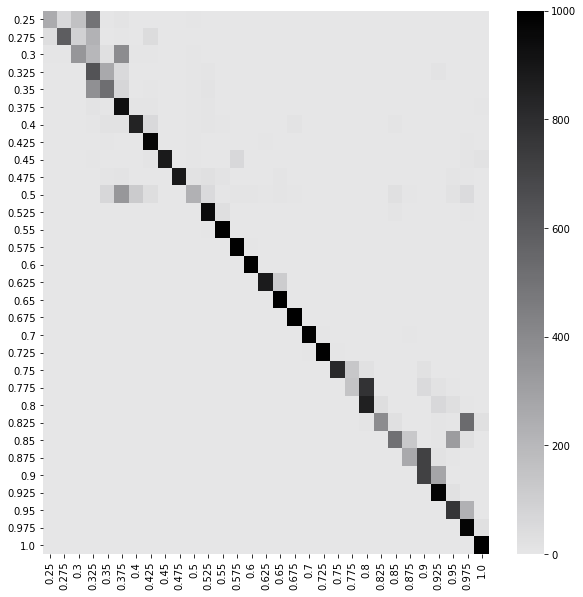

In [17]:
import seaborn as sn

plt.rcParams['figure.figsize'] = [10, 10]

cmap = sn.cubehelix_palette(50, hue=0.05, rot=0, light=0.9, dark=0, as_cmap=True)
df_cm = pd.DataFrame(conf_matrices['nearest'], np.around(classes, 3), np.around(classes, 3))
sn.heatmap(df_cm, cmap=cmap)

<AxesSubplot:>

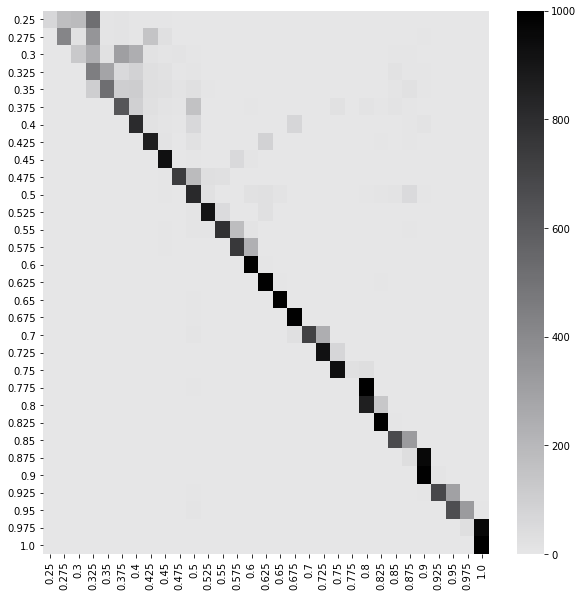

In [18]:
cmap = sn.cubehelix_palette(50, hue=0.05, rot=0, light=0.9, dark=0, as_cmap=True)
df_cm = pd.DataFrame(conf_matrices['bilinear'], np.around(classes, 3), np.around(classes, 3))
sn.heatmap(df_cm, cmap=cmap)

<AxesSubplot:>

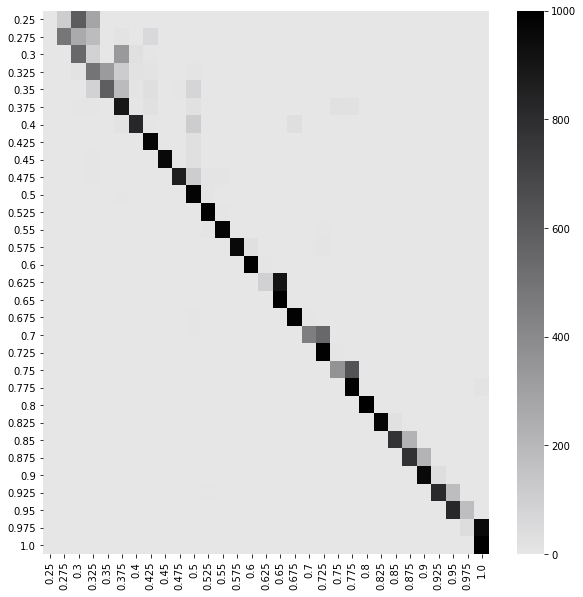

In [19]:
cmap = sn.cubehelix_palette(50, hue=0.05, rot=0, light=0.9, dark=0, as_cmap=True)
df_cm = pd.DataFrame(conf_matrices['bicubic'], np.around(classes, 3), np.around(classes, 3))
sn.heatmap(df_cm, cmap=cmap)

<AxesSubplot:>

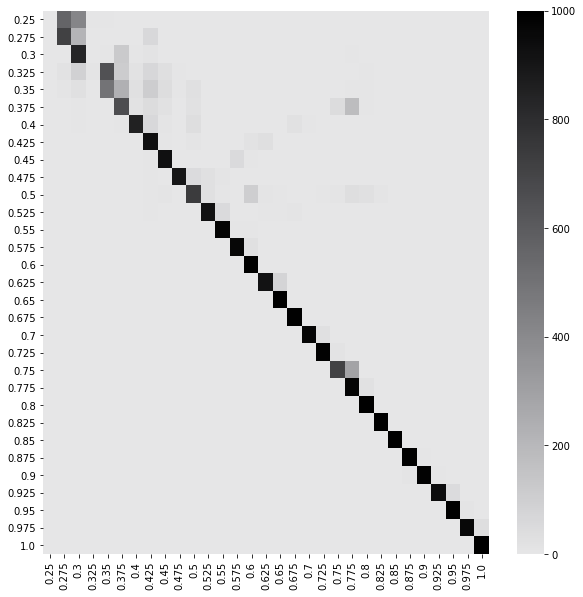

In [20]:
cmap = sn.cubehelix_palette(50, hue=0.05, rot=0, light=0.9, dark=0, as_cmap=True)
df_cm = pd.DataFrame(conf_matrices['lanczos3'], np.around(classes, 3), np.around(classes, 3))
sn.heatmap(df_cm, cmap=cmap)

<AxesSubplot:>

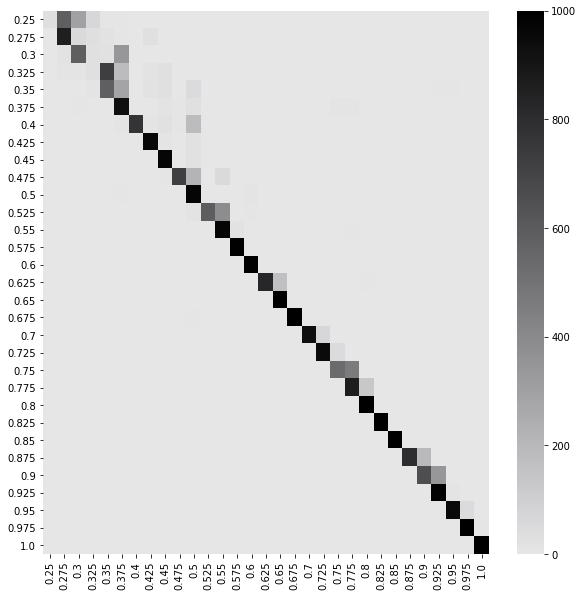

In [21]:
cmap = sn.cubehelix_palette(50, hue=0.05, rot=0, light=0.9, dark=0, as_cmap=True)
df_cm = pd.DataFrame(conf_matrices['random'], np.around(classes, 3), np.around(classes, 3))
sn.heatmap(df_cm, cmap=cmap)